# Import

In [1]:
import numpy as np
from scipy.stats import norm
import utils

import matplotlib.pyplot as plt
import plotly.graph_objs as go
from ipywidgets import widgets, HBox, VBox, Output

from importlib import reload

# Sanity check

## Parameters

In [2]:
params_glob = {'sigma':0.2, 'rate': 0.15, 'T': 1, 'strike': 100, 'S_0': 100}
params_LP = {'a0': 1, 'a1': 30, 'a2': 10, 'ksi': 3, 'X0': 10**6, 'Y0': 10**3, 'gamma': 10**(-8), 'fees_coeff': 0.05}
params_grid = {'n_paths': 10000, 'n_steps': 500}

In [3]:
params = {**params_glob, **params_grid}
option_type = 'call'

# Define payoff function
if option_type == 'call':
    g = lambda X, K : np.maximum(X-K, 0)
elif option_type == 'put':
    g = lambda X, K : np.maximum(K-X, 0)
else:
    raise ValueError

## Generate Paths

In [4]:
BM_type = 'geometric'  # 'geometric' or 'arithmetic'

sanityCheck_path_generator_obj = utils.Solver(**{**params_glob, **params_grid, **params_LP})
S = sanityCheck_path_generator_obj.external_mid_price_paths(BM_type=BM_type)

## European Option

In [5]:
print("Brownian Motion type:", BM_type, end='\n\n')

# European Call Option price by Monte Carlo
Call_Option_MC = np.mean(np.exp(-params['rate']*params['T'])*np.maximum(S[:,-1]-params['strike'], 0))
Put_Option_MC = np.mean(np.exp(-params['rate']*params['T'])*np.maximum(params['strike']-S[:,-1], 0))

IC_Call_Option_MC = np.array([-1.96,1.96])*np.sqrt(np.var(np.exp(-params['rate']*params['T'])*np.maximum(S[:,-1]-params['strike'], 0))/params['n_steps'])
IC_Put_Option_MC = np.array([-1.96,1.96])*np.sqrt(np.var(np.exp(-params['rate']*params['T'])*np.maximum(params['strike']-S[:,-1], 0))/params['n_steps'])

print(f"EU Call option price by Monte Carlo: {round(Call_Option_MC,2)} and confidence interval is {round(float(Call_Option_MC+IC_Call_Option_MC[0]),2),round(float(Call_Option_MC+IC_Call_Option_MC[1]),2)}")
print(f"EU Put option price by Monte Carlo: {round(Put_Option_MC,2)} and confidence interval is {round(float(Put_Option_MC+IC_Put_Option_MC[0]),2),round(float(Put_Option_MC+IC_Put_Option_MC[1]),2)}", end='\n\n')

# Exact solution
if BM_type == 'arithmetic':
    v = params['sigma'] * np.sqrt(params['T'])
    m = params['S_0']
    d = (m-params['strike'])/v

    Call_Exact = np.exp(-params['rate']*params['T'])*((m-params['strike'])*norm.cdf(d) + v*norm.pdf(d))
    Put_Exact = np.exp(-params['rate']*params['T'])*((params['strike']-m)*norm.cdf(-d) + v*norm.pdf(d))

elif BM_type == 'geometric':
    d_plus = (np.log(params['S_0']/params['strike']) + (params['rate'] + 0.5*params['sigma']**2)*params['T']) * (1/(params['sigma']*np.sqrt(params['T'])))
    d_minus = d_plus - params['sigma']*np.sqrt(params['T'])

    Call_Exact = params['S_0']*norm.cdf(d_plus) - params['strike']*np.exp(-params['rate']*params['T'])*norm.cdf(d_minus)
    Put_Exact = - params['S_0']*norm.cdf(-d_plus) + params['strike']*np.exp(-params['rate']*params['T'])*norm.cdf(-d_minus)

print(f"EU Call option price by closed form formula: {Call_Exact}")
print(f"EU Put option price by closed form formula: {Put_Exact}")

Brownian Motion type: geometric

EU Call option price by Monte Carlo: 16.13 and confidence interval is (14.64, 17.61)
EU Put option price by Monte Carlo: 2.49 and confidence interval is (2.0, 2.98)

EU Call option price by closed form formula: 16.355968471303683
EU Put option price by closed form formula: 2.4267661138094674


## Amercian Option

Price of US call option by Longstaff-Schwartz method: 16.133927362397102
Proportion of paths stopped before maturity: 4.0%


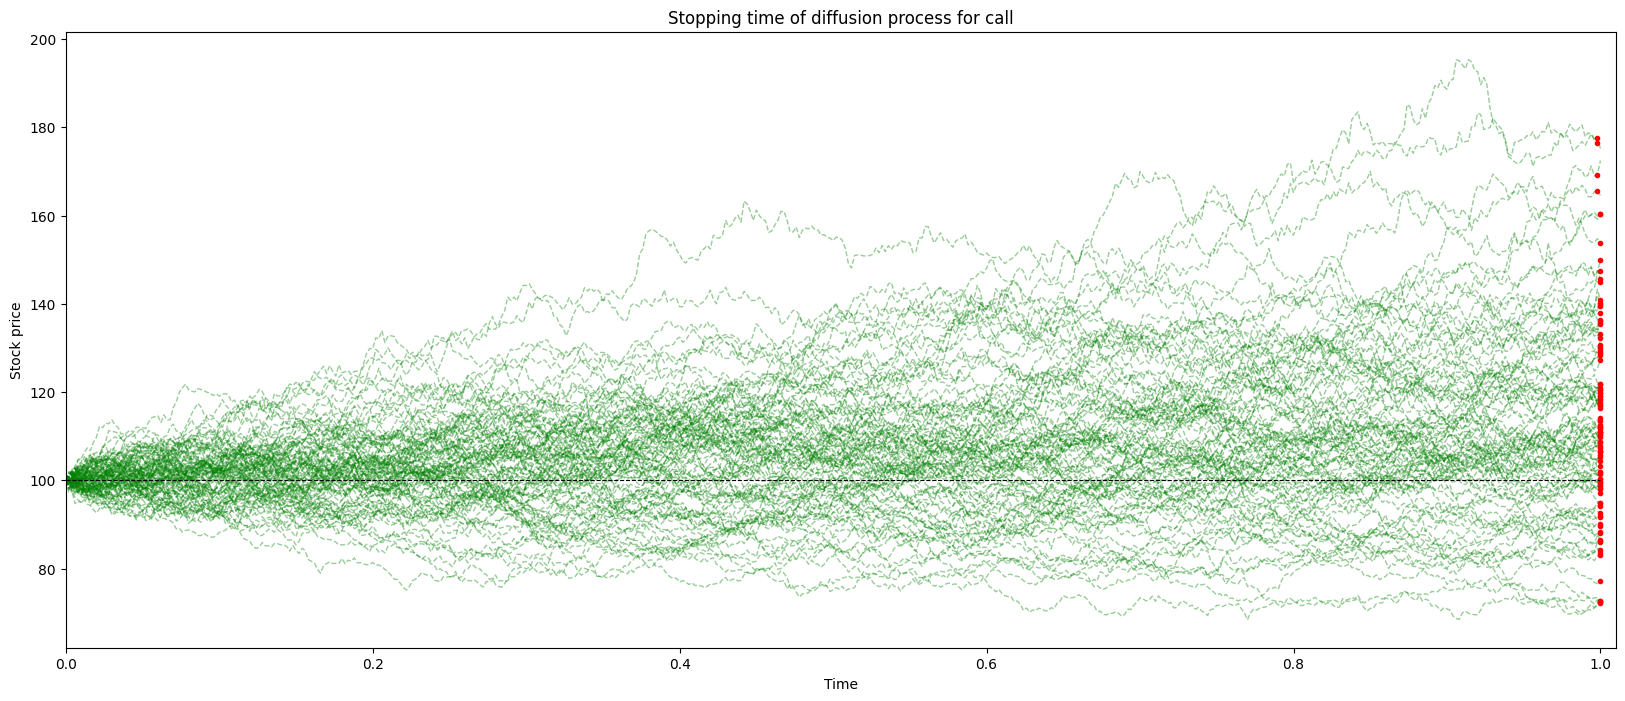

In [6]:
res = sanityCheck_path_generator_obj.longstaff_schwartz(paths=S, deg=2, problem_type='call')

print(f'Price of US {option_type} option by Longstaff-Schwartz method: {res["V0"]}')
print(f"Proportion of paths stopped before maturity: {100-round(np.sum(res['stopping_time'] == 500)/res['stopping_time'].shape[0],2)*100}%")

# Plot
fig, ax = plt.subplots(figsize=(20, 8))

nbr_path_plotted = 100
t_ = np.zeros(shape=(params['n_paths'], params['n_steps'] + 1))
t_[:,:] = np.linspace(0, params['T'], params['n_steps'] + 1)

for j in np.random.randint(0, high=params_grid['n_paths'], size=nbr_path_plotted, dtype=int):
        # Plot the paths before the optimal stopping time in green
        ax.plot(t_[j,:], S[j,:], 
                color='green', linestyle='--', linewidth=1, alpha=0.4)

        # Plot the paths after the optimal stopping time in red
        ax.plot(t_[j, int(res['stopping_time'][j])], S[j, int(res['stopping_time'][j])], 
                color='red', linestyle='--', marker='o', linewidth=1, markersize=3, alpha=1)

ax.set_xlim(left=0, right=params['T']+10**(-2))
ax.hlines(y=params['strike'], xmin=0, xmax=params['T'], color='black', linestyle='--', linewidth=0.8, label='Strike price')

# Add title and labels
ax.set_title(f'Stopping time of diffusion process for {option_type}')
ax.set_xlabel('Time')
ax.set_ylabel('Stock price')

# Show the plot
plt.show()

Price of US call option by Longstaff-Schwartz method: 16.11053959427154
Proportion of paths stopped before maturity: 30.0%


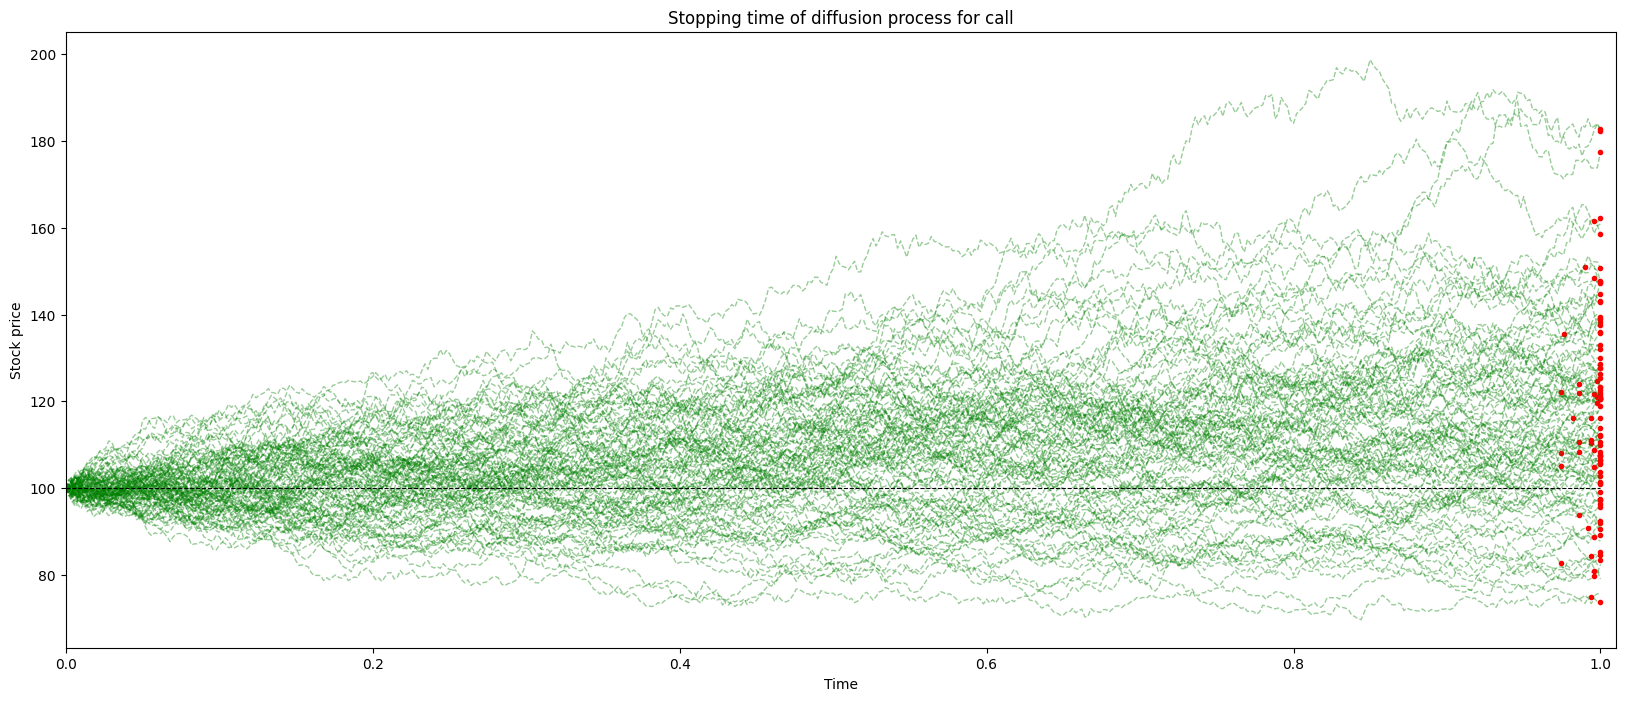

In [7]:
### M1 Philippe's code 

def american_option_longstaff_schwartz(S0, K, T, r, sigma, N, M, p, option_type='call'):
    """
    S0: Initial price of the underlying asset  
    K: Strike price  
    T: Maturity (in years)  
    r: Risk-free interest rate  
    sigma: Volatility of the underlying asset  
    N: Number of time steps  
    M: Number of Monte Carlo simulations  
    p: degree of the polynomial regression
    option_type: Option type ('call' or 'put')  
    return: Option price  
    """
    # Parameters
    dt = T / N  # time interval
    discount_factor = np.exp(-r * dt)  # factor to discount to the present

    # Monte-Carlo simulation
    np.random.seed(45)  # random results
    W = np.random.normal(0, 1, (M, N))  # gaussian noise
    S = np.zeros((M, N + 1))
    S[:, 0] = S0
    for t in range(1, N + 1):
       S[:, t] = S[:, t - 1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * W[:, t - 1])
            
    # Initialisation of Snell's envelope 
    Z = np.maximum(S[:, -1] - K, 0) if option_type == 'call' else np.maximum(K - S[:, -1], 0)
    
    tau_matrix = np.zeros_like(S)
    tau_matrix[:, -1] = 1


    # Longstaff-Schwartz
    for t in range(N - 1, 0, -1):
        itm = np.where(Z > 0)[0]  # In-the-money, we only keep positive pay-offs 
        if len(itm) == 0:
            continue

        # Regression of conditional expectation 
        X = S[itm, t]
        Y = Z[itm] * discount_factor # We discount to the present
        coeffs = np.polyfit(X, Y, p)  # polynomial of degree p
        continuation_values = np.polyval(coeffs, X) # Provides the value of the polynomial regression of the discounted conditional expectations

        # Calculation of immediate gains and make an optimal decision
        immediate_exercise = np.maximum(S[itm, t] - K, 0) if option_type == 'call' else np.maximum(K - S[itm, t], 0)
        Z[itm] = np.maximum(immediate_exercise, continuation_values) # induction to determine Snell's envelope

        stop_here = immediate_exercise >= continuation_values
        tau_matrix[itm, t] = stop_here.astype(int)
        

    # Option price at t = 0
    option_price = np.mean(Z) * np.exp(-r * dt)
    stopping_time = np.argmax(tau_matrix, axis=1)

    return {'V0':option_price, 'tau_matrix':tau_matrix, 'stopping_time':stopping_time}

# Input parameters
S0 = params['S_0']         # Initial price of the underlying asset
K = params['strike']          # Strike price
T = params['T']          # Maturity (1 year)
r = params['rate']        # Risk-free interest rate (5%)
sigma = params['sigma']      # Volatility (20%)
N = params['n_steps']           # Number of time steps
M = params['n_paths']        # Number of Monte Carlo simulations
p = 2           # 7-order regression because p>7 provide an over-fit regression

res = american_option_longstaff_schwartz(S0, K, T, r, sigma, N, M, p, option_type)

print(f'Price of US {option_type} option by Longstaff-Schwartz method: {res["V0"]}')
print(f"Proportion of paths stopped before maturity: {100-round(np.sum(res['stopping_time'] == 500)/res['stopping_time'].shape[0],2)*100}%")

# Plot
fig, ax = plt.subplots(figsize=(20, 8))

nbr_path_plotted = 100
t_ = np.zeros(shape=(params['n_paths'], params['n_steps'] + 1))
t_[:,:] = np.linspace(0, params['T'], params['n_steps'] + 1)

for j in np.random.randint(0, high=params_grid['n_paths'], size=nbr_path_plotted, dtype=int):
        # Plot the paths before the optimal stopping time in green
        ax.plot(t_[j,:], S[j,:], 
                color='green', linestyle='--', linewidth=1, alpha=0.4)

        # Plot the paths after the optimal stopping time in red
        ax.plot(t_[j, int(res['stopping_time'][j])], S[j, int(res['stopping_time'][j])], 
                color='red', linestyle='--', marker='o', linewidth=1, markersize=3, alpha=1)

ax.set_xlim(left=0, right=params['T']+10**(-2))
ax.hlines(y=params['strike'], xmin=0, xmax=params['T'], color='black', linestyle='--', linewidth=0.8, label='Strike price')

# Add title and labels
ax.set_title(f'Stopping time of diffusion process for {option_type}')
ax.set_xlabel('Time')
ax.set_ylabel('Stock price')

# Show the plot
plt.show()

## LS Paper

In [8]:
reload(utils)

<module 'utils' from '/Users/sebastien/Desktop/AMM-Project/Code/utils.py'>

In [9]:
# Example in the paper of Longstaff-Scwhartz

LS_solver_obj = utils.Solver(**{**{'sigma': 0.2, 'rate': 0.06, 'T': 3, 'strike': 1.1, 'S_0': 1}, 
                                **{'n_paths': 8, 'n_steps': 3}, 
                                **params_LP})

S_LS_paper = np.array([[1, 1.09, 1.08, 1.34],
                        [1, 1.16, 1.26, 1.54],
                        [1, 1.22, 1.07, 1.03],
                        [1, 0.93, 0.97, 0.92],
                        [1, 1.11, 1.56, 1.52],
                        [1, 0.76, 0.77, 0.90],
                        [1, 0.92, 0.84, 1.01],
                        [1, 0.88, 1.22, 1.34]])

option_type = 'put'

# Define payoff function
if option_type == 'call':
    g = lambda X, K : np.maximum(X-K,0)
elif option_type == 'put':
    g = lambda X, K : np.maximum(K-X,0)
else:
    raise ValueError

res_LS = LS_solver_obj.longstaff_schwartz(paths=S_LS_paper, deg=2, problem_type='put')
print(f'Price of US {option_type} option by Longstaff-Schwartz method: {round(res_LS["V0"],4)} vs on LS paper: 0.1144')

Price of US put option by Longstaff-Schwartz method: 0.1144 vs on LS paper: 0.1144


# AMM Simulation Process

## Parameters

In [101]:
# Parameters
params_glob = {'sigma': 0.2*10**3, 'rate': 0.05, 'T': 1, 'strike': None, 'S_0': 10**3}
params_LP = {'a0': 1, 'a1': 30, 'a2': 10, 'ksi': 1, 'X0': 10**6, 'Y0': 10**3, 'gamma': 10**(-8), 'fees_coeff': 0.01}
params_grid = {'n_paths': 10000, 'n_steps': 1000}

BM_type = 'arithmetic'  # 'geometric' or 'arithmetic'

## Longstaff-Scwhartz

In [102]:
reload(utils)

# Create solver object in order to apply Longstaff-Schwartz method and Euler
amm_solver_obj = utils.Solver(**{**params_glob, **params_grid, **params_LP})

In [103]:
# Solving the AMM problem using Longstaff-Schwartz method
amm_solver_obj.amm_model(BM_type=BM_type)

amm_paths = amm_solver_obj.get_paths()['amm_model_0']
res_LS = amm_solver_obj.longstaff_schwartz(paths=amm_paths, deg=2, problem_type='amm')

# Prepare data for plotting
external_mid_price_S = amm_solver_obj.get_paths()['external_mid_price_S']
asset_Z = amm_solver_obj.get_paths()['asset_Z']
fees_R = amm_solver_obj.get_paths()['fees']

input_params = amm_solver_obj.get_params()

t_ = np.zeros(shape=(params_grid['n_paths'], params_grid['n_steps'] + 1))
t_[:,:] = np.linspace(0, params_glob['T'], params_grid['n_steps'] + 1)

In [104]:
x = t_[np.arange(params_grid['n_paths']), res_LS['stopping_time']]       
y = external_mid_price_S[np.arange(params_grid['n_paths']), res_LS['stopping_time']] #- asset_Z[np.arange(params_grid['n_paths']), res_LS['stopping_time']]
z = fees_R[np.arange(params_grid['n_paths']), res_LS['stopping_time']] 

# Plotting the results in 3D
fig = go.Figure(data=go.Scatter3d(
    x=x,       
    y=y,       
    z=z, 
    mode='markers',
    line=dict(color='blue'),
    marker=dict(size=1)
))

fig.update_layout(
    scene=dict(
        xaxis_title='Time',
        yaxis_title='S at exit time',
        zaxis_title='Fees at exit time',
        xaxis=dict(range=[0, params_glob['T']]),
    ),
    scene_camera=dict(
        eye=dict(x=1.5, y=1.5, z=1.5),
        center=dict(x=0, y=0, z=-0.2) 
    ),
    margin=dict(l=0, r=0, t=0, b=0)
)

params_text = (
    f"sigma: {input_params['sigma']}<br>"
    f"rate: {input_params['rate']}<br>"
    f"T: {input_params['T']}<br>"
    f"a0: {input_params['a0']}<br>"
    f"a1: {input_params['a1']}<br>"
    f"a2: {input_params['a2']}<br>"
    f"ksi: {input_params['ksi']}<br>"
    f"X0: {input_params['X0']}<br>"
    f"Y0: {input_params['Y0']}<br>"
    f"Initial local price: {input_params['X0']/input_params['Y0']}<br>"
)

fig.add_annotation(
    text=params_text,
    xref="paper", yref="paper",
    align="left",
    showarrow=False,
    x=0, y=0,                       
    font=dict(size=12),
    opacity=0.8
)

fig.show()

## Euler

In [43]:
value_function_euler = amm_solver_obj.euler(delta=0.01, h=10, scale_factor=0.5)

In [46]:
np.argmax((value_function_euler[:, value_function_euler.shape[1]//2, :] == 0).astype(int), axis=1)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [45]:
value_function_euler[:, :, :]

array([[[ 8.41802670e+006,  8.09511738e+006,  7.77820804e+006, ...,
         -9.66484597e+002, -9.96715154e+002, -1.02693905e+003],
        [-2.42270321e+005, -2.37885566e+005, -2.33502092e+005, ...,
          9.71787553e+006,  1.02407723e+007,  1.07756753e+007],
        [ 8.58805124e+006,  8.26357075e+006,  7.94509293e+006, ...,
         -5.60679968e+010, -6.01088948e+010, -6.43258609e+010],
        ...,
        [-1.04871349e+007,  1.57057139e+162,  1.03544063e+163, ...,
          6.46974364e+213,  1.99222957e+214,  5.76781937e+214],
        [ 1.64012799e+007, -4.60757243e+165, -3.04872219e+166, ...,
         -2.67584559e+217, -8.39911404e+217, -2.47438075e+218],
        [-1.66803705e+007,  1.36410843e+169,  9.05872332e+169, ...,
          1.09930954e+221,  3.51670402e+221,  1.05408025e+222]],

       [[ 8.41802670e+006,  8.09511738e+006,  7.77820804e+006, ...,
         -9.66484597e+002, -9.96715154e+002, -1.02693905e+003],
        [-2.42270321e+005, -2.37885566e+005, -2.33502092e+005

In [35]:
value_function_euler

array([[[ 8.87775115e+006,  8.54397351e+006,  8.21619585e+006, ...,
         -8.55905426e+002, -8.86168551e+002, -9.16424078e+002],
        [-2.52985293e+005, -2.48533658e+005, -2.44083484e+005, ...,
          9.70284913e+006,  1.02256770e+007,  1.07605120e+007],
        [ 9.05928914e+006,  8.72402009e+006,  8.39475410e+006, ...,
         -5.59806758e+010, -6.00196563e+010, -6.42346963e+010],
        ...,
        [-1.09869182e+007,  1.56652228e+162,  1.03277115e+163, ...,
          6.45985438e+213,  1.98930298e+214,  5.75964505e+214],
        [ 1.73669073e+007, -4.59619058e+165, -3.04119108e+166, ...,
         -2.67175932e+217, -8.38678107e+217, -2.47087398e+218],
        [-1.76622842e+007,  1.36087364e+169,  9.03724184e+169, ...,
          1.09763244e+221,  3.51154249e+221,  1.05258638e+222]],

       [[ 8.87775115e+006,  8.54397351e+006,  8.21619585e+006, ...,
         -8.55905426e+002, -8.86168551e+002, -9.16424078e+002],
        [-2.52985293e+005, -2.48533658e+005, -2.44083484e+005

In [47]:
value_function_euler[-2,29,:]

array([-6.08378986e+005, -5.90816034e+005, -5.73253082e+005,
       -5.55690130e+005, -5.38127178e+005, -5.20564226e+005,
       -5.03001273e+005, -4.85438321e+005, -4.67875369e+005,
       -4.50312417e+005, -4.32749465e+005, -4.15186513e+005,
       -3.97623561e+005, -3.80060608e+005, -3.62497656e+005,
       -3.44934704e+005, -3.27371752e+005, -3.09808800e+005,
       -2.92245848e+005, -2.74682896e+005, -2.57119944e+005,
       -2.39556991e+005, -2.21994039e+005, -2.04431087e+005,
       -1.86868135e+005, -1.69305183e+005, -1.51742231e+005,
       -1.34179279e+005, -1.16616326e+005, -9.90533744e+004,
       -8.14904222e+004, -6.39274701e+004, -4.63645180e+004,
       -2.88015658e+004, -1.12386137e+004,  6.32433844e+003,
        2.38872906e+004,  4.14502427e+004,  5.90131948e+004,
        7.65761470e+004,  9.41390991e+004,  1.11702051e+005,
       -4.71860194e+009, -6.84319389e+016, -3.37811706e+024,
       -4.03508059e+033, -1.91200125e+042, -1.18707892e+051,
       -1.04839945e+061,

### Raw simulation

In [18]:
# Create a 3D surface plot for each jump
fig = go.Figure()

for jump in np.arange(0, L+1):

    fig.add_trace(go.Scatter(x=S_matrix, y=V_matrix[0, jump, :], mode='markers', name=f'y_{jump}'))

# Update layout for better visualization
fig.update_layout(
    title="Value Function at t=0",
    xaxis_title="Stock Price",
    yaxis_title="Value function at t=0",
)

# Show the plot
fig.show()